UPLOADING THE DATASET

In [24]:
!mkdir Dataset/Cracks
!mkdir Dataset/NonCracks

#**Part A - Image Feature Extraction and Classification**

###**Import Libraries**

In [25]:
# Import required libraries

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


###**Set Dataset Paths**

In [26]:
# Dataset paths

crack_path = "Dataset/Cracks"
noncrack_path = "Dataset/NonCracks"

print("Crack folder:", crack_path)
print("Non-Crack folder:", noncrack_path)

Crack folder: Dataset/Cracks
Non-Crack folder: Dataset/NonCracks


###**Count Images**

In [27]:
# Get image filenames

crack_images = os.listdir(crack_path)
noncrack_images = os.listdir(noncrack_path)

print("Number of Crack images:", len(crack_images))
print("Number of Non-Crack images:", len(noncrack_images))

Number of Crack images: 200
Number of Non-Crack images: 200


###**Read and Inspect One Image**

In [28]:
sample_path = os.path.join(crack_path, crack_images[0])

image = cv2.imread(sample_path)

print("Image shape:", image.shape)
print("Height:", image.shape[0])
print("Width:", image.shape[1])
print("Channels:", image.shape[2])

Image shape: (448, 448, 3)
Height: 448
Width: 448
Channels: 3


###**Resize and Grayscale**

In [29]:
image_resized = cv2.resize(image, (128, 128))

gray_image = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)

print("Resized image shape:", image_resized.shape)
print("Grayscale image shape:", gray_image.shape)

Resized image shape: (128, 128, 3)
Grayscale image shape: (128, 128)


###**Display Image**

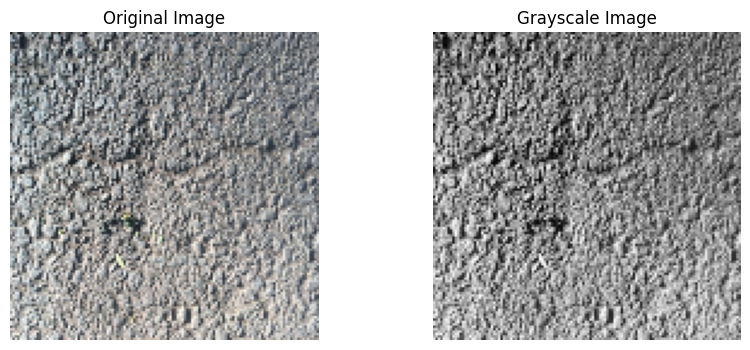

In [30]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

###**Feature Extraction Function**

In [31]:
def extract_features(image_path):

    image = cv2.imread(image_path)
    image = cv2.resize(image, (128, 128))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    return [
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

###**Create Feature Dataset**

In [32]:
data = []

for filename in crack_images:
    path = os.path.join(crack_path, filename)
    features = extract_features(path)
    data.append(features + ["Crack", filename])

for filename in noncrack_images:
    path = os.path.join(noncrack_path, filename)
    features = extract_features(path)
    data.append(features + ["Non-Crack", filename])

columns = [
    "mean_brightness",
    "contrast",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density",
    "label",
    "filename"
]

image_features = pd.DataFrame(data, columns=columns)

print("Feature dataset shape:", image_features.shape)

display(image_features.head())

Feature dataset shape: (400, 11)


,mean_brightness,contrast,min_intensity,max_intensity,median_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label,filename
0,143.220459,47.688031,23,253,146.0,0.024902,0.122131,6207,0.378845,Crack,IMG_8442 resized_448.jpg
1,170.507385,22.146012,82,252,169.0,0.000000,0.096741,4361,0.266174,Crack,IMG_8506 resized_448.jpg
2,151.934448,41.121685,32,251,156.0,0.000488,0.122070,6172,0.376709,Crack,IMG_8455 resized_448.jpg
3,181.446533,23.984791,92,253,183.0,0.000000,0.218872,5426,0.331177,Crack,IMG_8493 resized_448.jpg
4,136.757446,32.159860,2,244,136.0,0.014221,0.026978,5681,0.346741,Crack,IMG_20180514_170100812_HDR resized_448.jpg


###**Check Feature Dataset**

In [33]:
print("Class distribution:")
print(image_features["label"].value_counts())

print("\nMissing values:")
print(image_features.isnull().sum())

Class distribution:
label
Crack        200
Non-Crack    200
Name: count, dtype: int64

Missing values:
mean_brightness       0
contrast              0
min_intensity         0
max_intensity         0
median_intensity      0
dark_pixel_ratio      0
bright_pixel_ratio    0
edge_count            0
edge_density          0
label                 0
filename              0
dtype: int64


###**Save Feature Dataset**

In [34]:
image_features.to_csv("image_features.csv", index=False)

print("Feature dataset saved.")

Feature dataset saved.


###**Prepare X and y**

In [35]:
X = image_features.drop(columns=["label", "filename"])
y = image_features["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 9)
y shape: (400,)


###**Train-Test Split**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 9)
Testing data: (80, 9)


###**Logistic Regression And Random Forest**

In [37]:

# Logistic Regression + Random Forest

import os
import cv2
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 1. Image paths

crack_path = "Dataset/Cracks"
noncrack_path = "Dataset/NonCracks"

crack_images = os.listdir(crack_path)
noncrack_images = os.listdir(noncrack_path)

# 2. Extract image features

data = []

for filename in crack_images:

    path = os.path.join(crack_path, filename)

    image = cv2.imread(path)
    image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    data.append([
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density,
        "Crack",
        filename
    ])


for filename in noncrack_images:

    path = os.path.join(noncrack_path, filename)

    image = cv2.imread(path)
    image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / gray.size

    data.append([
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density,
        "Non-Crack",
        filename
    ])

# 3. Create feature dataframe

columns = [
    "mean_brightness",
    "contrast",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density",
    "label",
    "filename"
]

image_features = pd.DataFrame(data, columns=columns)

print("Image feature dataset created.")
print("Shape:", image_features.shape)

# 4. Separate X and y

X = image_features.drop(columns=["label", "filename"])
y = image_features["label"]

# 5. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# 6. Logistic Regression

model_lr = LogisticRegression(max_iter=1000)

start = time.time()
model_lr.fit(X_train, y_train)
training_time_lr = time.time() - start

start = time.time()
y_pred_lr = model_lr.predict(X_test)
prediction_time_lr = time.time() - start

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="Crack")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="Crack")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="Crack")

# 7. Random Forest

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.time()
model_rf.fit(X_train, y_train)
training_time_rf = time.time() - start

start = time.time()
y_pred_rf = model_rf.predict(X_test)
prediction_time_rf = time.time() - start

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label="Crack")
recall_rf = recall_score(y_test, y_pred_rf, pos_label="Crack")
f1_rf = f1_score(y_test, y_pred_rf, pos_label="Crack")

# 8. Display results

print("\nLOGISTIC REGRESSION")
print("Accuracy :", round(accuracy_lr, 3))
print("Precision:", round(precision_lr, 3))
print("Recall   :", round(recall_lr, 3))
print("F1 Score :", round(f1_lr, 3))
print("Training Time:", round(training_time_lr, 4), "seconds")
print("Prediction Time:", round(prediction_time_lr, 4), "seconds")

print("\nRANDOM FOREST")
print("Accuracy :", round(accuracy_rf, 3))
print("Precision:", round(precision_rf, 3))
print("Recall   :", round(recall_rf, 3))
print("F1 Score :", round(f1_rf, 3))
print("Training Time:", round(training_time_rf, 4), "seconds")
print("Prediction Time:", round(prediction_time_rf, 4), "seconds")

Image feature dataset created.
Shape: (400, 11)
Training data: (320, 9)
Testing data: (80, 9)

LOGISTIC REGRESSION
Accuracy : 0.637
Precision: 0.622
Recall   : 0.7
F1 Score : 0.659
Training Time: 0.2492 seconds
Prediction Time: 0.0022 seconds

RANDOM FOREST
Accuracy : 0.938
Precision: 0.949
Recall   : 0.925
F1 Score : 0.937
Training Time: 0.231 seconds
Prediction Time: 0.0084 seconds


###**Compare Both Models**

In [38]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf],
    "Training Time": [training_time_lr, training_time_rf],
    "Prediction Time": [prediction_time_lr, prediction_time_rf]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Logistic Regression,0.638,0.622,0.700,0.659,0.249,0.002
1,Random Forest,0.938,0.949,0.925,0.937,0.231,0.008


###**Canny Edge Detection Visualization**

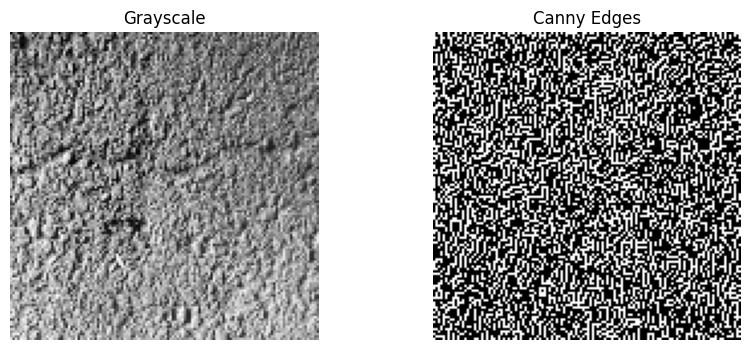

In [39]:
sample_path = os.path.join(crack_path, crack_images[0])

image = cv2.imread(sample_path)
image = cv2.resize(image, (128, 128))

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

###**Save Canny Image**

In [41]:
cv2.imwrite("canny_edges.png", edges)

print("Canny image saved.")

Canny image saved.


In [42]:
print(image_features["label"].value_counts())

label
Crack        200
Non-Crack    200
Name: count, dtype: int64


###**Graph For comparison**

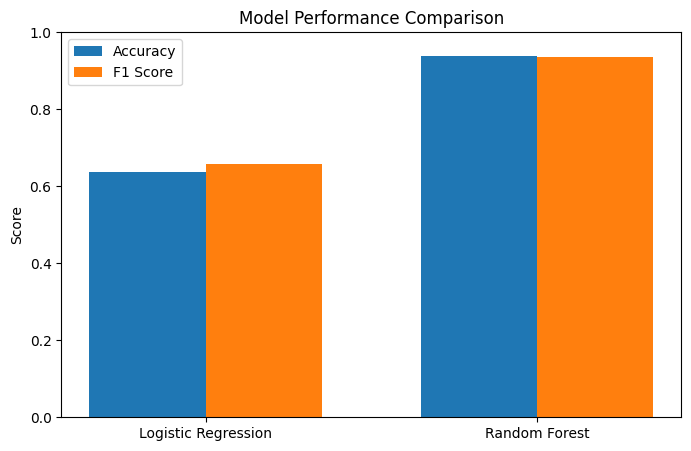

In [43]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]

accuracy = [accuracy_lr, accuracy_rf]
f1_score_values = [f1_lr, f1_rf]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_score_values, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

#**Part B - Text Vectorization and Spam Classification**

###**Load and Inspect Dataset**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
emails = pd.read_csv("emails.csv")

print("Dataset shape:", emails.shape)

print("\nFirst 5 rows:")
display(emails.head())

print("\nColumn names:")
print(emails.columns.tolist()[:20])

print("\nTarget distribution:")
print(emails["Prediction"].value_counts(dropna=False))

Dataset shape: (5172, 3002)

First 5 rows:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']

Target distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


###**Check Missing Values**

In [45]:
print("Missing values in target:")
print(emails["Prediction"].isna().sum())

print("\nTotal missing values:")
print(emails.isna().sum().sum())

Missing values in target:
0

Total missing values:
0


###**Check spam/non-spam distribution**

Spam/Non-Spam Distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


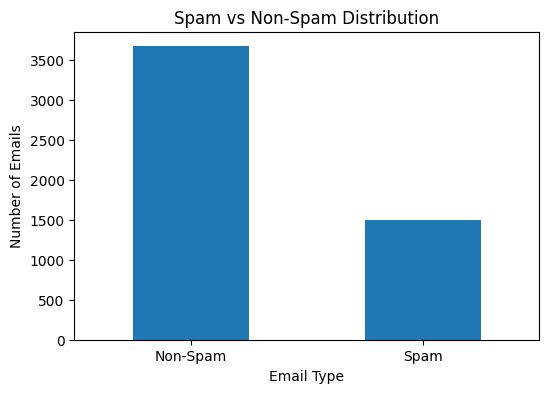

In [46]:
# Remove rows where target is missing
emails = emails.dropna(subset=["Prediction"])

# Convert target to integer
emails["Prediction"] = emails["Prediction"].astype(int)

print("Spam/Non-Spam Distribution:")
print(emails["Prediction"].value_counts())

# Plot distribution
plt.figure(figsize=(6, 4))

emails["Prediction"].value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1], ["Non-Spam", "Spam"], rotation=0)
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.title("Spam vs Non-Spam Distribution")

plt.show()

###**Prepare Features and Target**

In [47]:
# Features
X = emails.drop(columns=["Email No.", "Prediction"])

# Target
y = emails["Prediction"]

# Replace missing feature values with 0
X = X.fillna(0)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5172, 3000)
Target shape: (5172,)


###**Train-Test Split**

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4137, 3000)
Testing data: (1035, 3000)


###**Train Logistic Regression**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import time

# Create model
model = LogisticRegression(max_iter=1000)

# Training time
start_train = time.time()

model.fit(X_train, y_train)

train_time = time.time() - start_train

# Prediction time
start_pred = time.time()

y_pred = model.predict(X_test)

prediction_time = time.time() - start_pred

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression")
print("-----------------------------")
print("Number of features:", X.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("Training Time:", round(train_time, 4), "seconds")
print("Prediction Time:", round(prediction_time, 4), "seconds")

Logistic Regression
-----------------------------
Number of features: 3000
Accuracy: 0.9826
Precision: 0.9578
Recall: 0.9833
F1 Score: 0.9704
Training Time: 22.3286 seconds
Prediction Time: 0.1435 seconds


###**Predictions**

In [50]:
# Prediction
start_pred = time.time()

y_pred = model.predict(X_test)

prediction_time = time.time() - start_pred

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Prediction completed")

print("\nEvaluation Results")
print("------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("\nPrediction Time:", round(prediction_time, 4), "seconds")

Prediction completed

Evaluation Results
------------------
Accuracy: 0.9826
Precision: 0.9578
Recall: 0.9833
F1 Score: 0.9704

Prediction Time: 0.0444 seconds


###**Confusion Matrix**

Confusion Matrix:
[[722  13]
 [  5 295]]


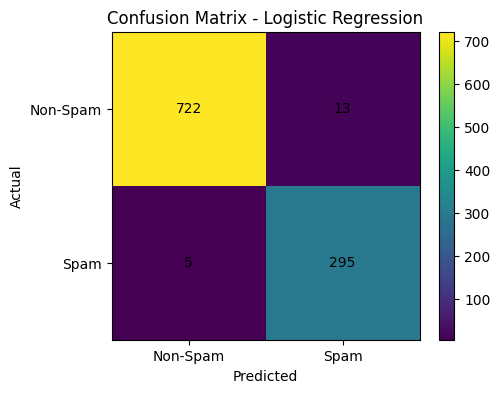

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

###**Results**

In [52]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Number of Features": [X.shape[1]],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "Training Time (s)": [train_time],
    "Prediction Time (s)": [prediction_time]
})

display(results)

,Model,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,3000,0.982609,0.957792,0.983333,0.970395,22.328612,0.044415


#**Part C - Improve the Representation**

###**Normalize the Features**

In [53]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Normalized number of features:", X_train_scaled.shape[1])

Original number of features: 3000
Normalized number of features: 3000


###**Train Logistic Regression with Normalized Features**

In [54]:
# Create improved model
scaled_model = LogisticRegression(max_iter=1000)

# Training time
start_train = time.time()

scaled_model.fit(X_train_scaled, y_train)

scaled_train_time = time.time() - start_train

# Prediction time
start_pred = time.time()

scaled_pred = scaled_model.predict(X_test_scaled)

scaled_prediction_time = time.time() - start_pred

print("Normalized Logistic Regression completed")

Normalized Logistic Regression completed


###**Evaluate Improved Model**

In [55]:
scaled_accuracy = accuracy_score(y_test, scaled_pred)
scaled_precision = precision_score(y_test, scaled_pred)
scaled_recall = recall_score(y_test, scaled_pred)
scaled_f1 = f1_score(y_test, scaled_pred)

print("Improved Model Results")
print("----------------------")
print("Accuracy:", round(scaled_accuracy, 4))
print("Precision:", round(scaled_precision, 4))
print("Recall:", round(scaled_recall, 4))
print("F1 Score:", round(scaled_f1, 4))
print("Training Time:", round(scaled_train_time, 4), "seconds")
print("Prediction Time:", round(scaled_prediction_time, 4), "seconds")

Improved Model Results
----------------------
Accuracy: 0.9662
Precision: 0.9206
Recall: 0.9667
F1 Score: 0.9431
Training Time: 3.01 seconds
Prediction Time: 0.0116 seconds


###**Compare Original and Improved Approach**

In [56]:
comparison = pd.DataFrame({
    "Approach": [
        "Original Numerical Features",
        "Normalized Features"
    ],
    "Number of Features": [
        X.shape[1],
        X.shape[1]
    ],
    "Accuracy": [
        accuracy,
        scaled_accuracy
    ],
    "Precision": [
        precision,
        scaled_precision
    ],
    "Recall": [
        recall,
        scaled_recall
    ],
    "F1 Score": [
        f1,
        scaled_f1
    ],
    "Training Time (s)": [
        train_time,
        scaled_train_time
    ],
    "Prediction Time (s)": [
        prediction_time,
        scaled_prediction_time
    ]
})

display(comparison)

,Approach,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Original Numerical Features,3000,0.982609,0.957792,0.983333,0.970395,22.328612,0.044415
1,Normalized Features,3000,0.966184,0.920635,0.966667,0.943089,3.009959,0.011584


###**Comparison Graph**

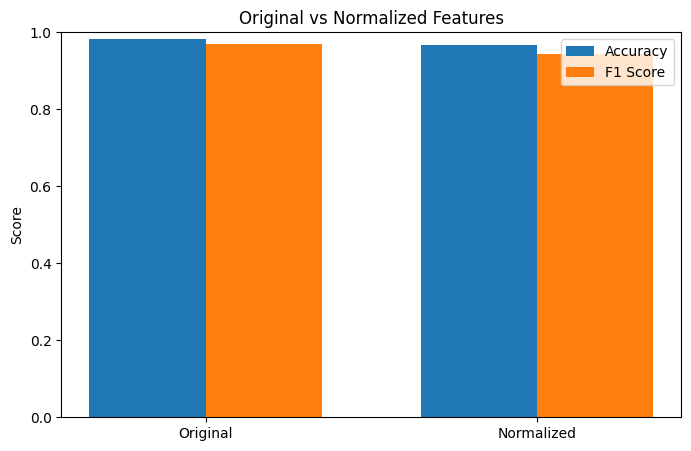

In [57]:
approaches = ["Original", "Normalized"]

accuracy_values = [accuracy, scaled_accuracy]
f1_values = [f1, scaled_f1]

x = np.arange(len(approaches))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, accuracy_values, width, label="Accuracy")
plt.bar(x + width/2, f1_values, width, label="F1 Score")

plt.xticks(x, approaches)
plt.ylabel("Score")
plt.title("Original vs Normalized Features")
plt.ylim(0, 1)
plt.legend()

plt.show()

###**Confusion Matrix for Improved Model**

Confusion Matrix - Normalized Features:
[[710  25]
 [ 10 290]]


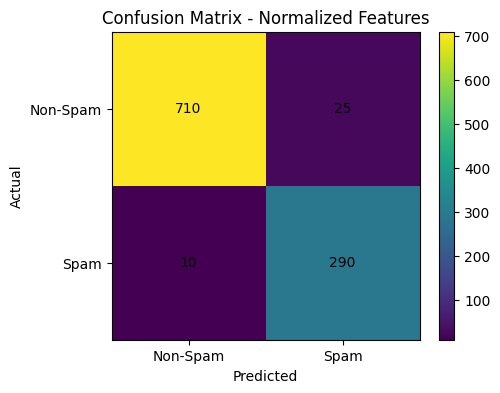

In [58]:
scaled_cm = confusion_matrix(y_test, scaled_pred)

print("Confusion Matrix - Normalized Features:")
print(scaled_cm)

plt.figure(figsize=(5, 4))

plt.imshow(scaled_cm)

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Normalized Features")

for i in range(2):
    for j in range(2):
        plt.text(j, i, scaled_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()